In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import seaborn as sns

# PHI-4 Visualization

## Calculate average scores per prompt (Zero and Instruction Shot)

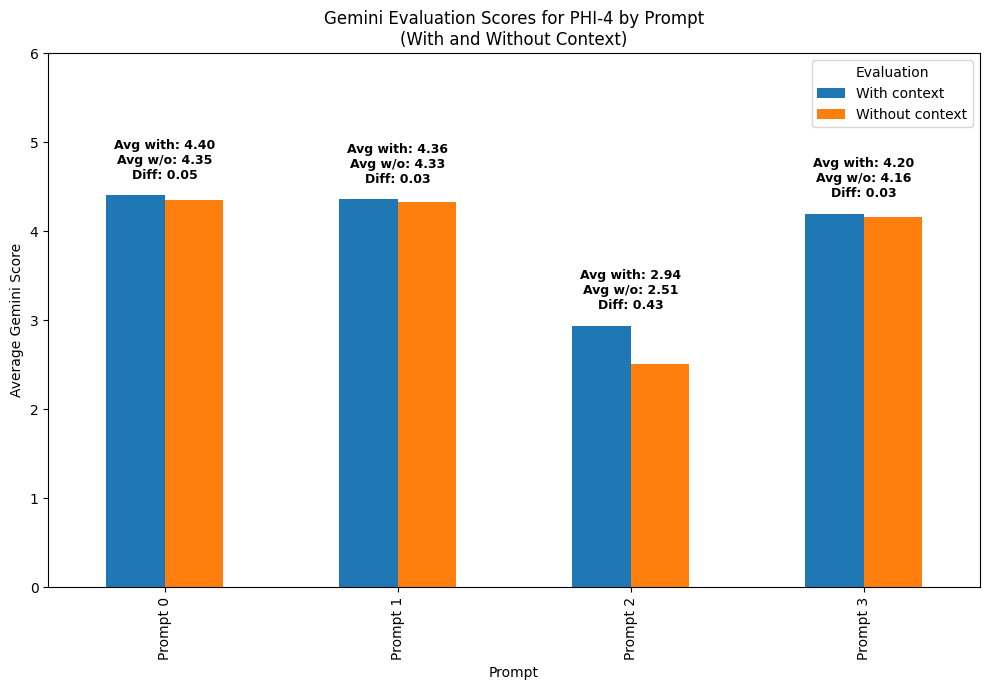

Best prompt with context in Zero_shot technique: ('Prompt 0', np.float64(4.402061855670103))


In [8]:
df = pd.read_csv('phi-4/phi-4_translations_with_eval.csv')

prompt_nums = [0, 1, 2, 3]
with_context_means = []
no_context_means = []
differences = []

for p in prompt_nums:
    wc = df[f'Modern_Italian_{p}_gemini_eval'].mean()
    nc = df[f'Modern_Italian_{p}_gemini_eval_no_context'].mean()
    with_context_means.append(wc)
    no_context_means.append(nc)
    differences.append(wc - nc)

plot_df = pd.DataFrame({
    'Prompt': [f'Prompt {p}' for p in prompt_nums],
    'With context': with_context_means,
    'Without context': no_context_means,
    'Difference': differences
})

# Plotting
ax = plot_df.set_index('Prompt')[['With context', 'Without context']].plot(kind='bar', figsize=(10,7))
plt.title('Gemini Evaluation Scores for PHI-4 by Prompt\n(With and Without Context)')
plt.ylabel('Average Gemini Score')
plt.ylim(0, 6)
plt.xlabel('Prompt')
plt.legend(title='Evaluation')
plt.tight_layout()

for idx, row in plot_df.iterrows():
    x = idx  
    y = max(row['With context'], row['Without context'])
    summary = (
        f"Avg with: {row['With context']:.2f}\n"
        f"Avg w/o: {row['Without context']:.2f}\n"
        f"Diff: {row['Difference']:.2f}"
    )
    
    plt.text(x, y+0.15, summary, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

best_zero_shot_prompt_wc = plot_df.loc[plot_df['With context'].idxmax(), 'Prompt'], plot_df['With context'].max()
print(f"Best prompt with context in Zero_shot technique: {best_zero_shot_prompt_wc}")

## Calculate average scores per prompt (Few-Shot)

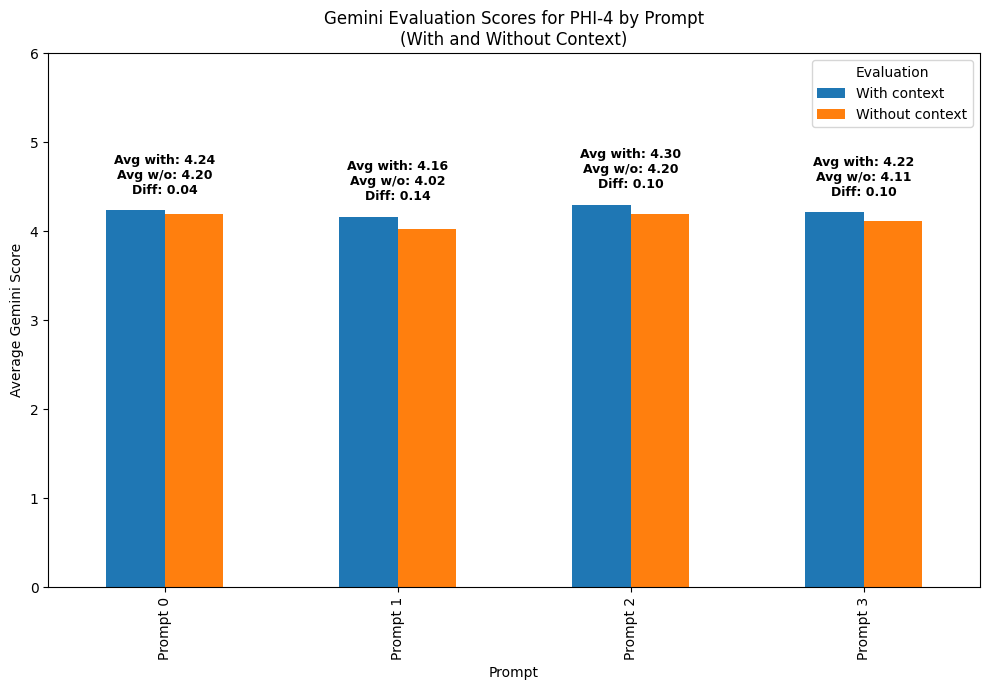

Best prompt with context in Few_shot technique: ('Prompt 2', np.float64(4.298969072164948))


In [9]:
df = pd.read_csv('phi-4/phi-4_translations_fewshot_with_eval.csv')

prompt_nums = [0, 1, 2, 3]
with_context_means = []
no_context_means = []
differences = []
best_prompt = []

for p in prompt_nums:
    wc = df[f'Modern_Italian_{p}_gemini_eval'].mean()
    nc = df[f'Modern_Italian_{p}_gemini_eval_no_context'].mean()
    with_context_means.append(wc)
    no_context_means.append(nc)
    differences.append(wc - nc)



plot_df = pd.DataFrame({
    'Prompt': [f'Prompt {p}' for p in prompt_nums],
    'With context': with_context_means,
    'Without context': no_context_means,
    'Difference': differences
})

# Plotting
ax = plot_df.set_index('Prompt')[['With context', 'Without context']].plot(kind='bar', figsize=(10,7))
plt.title('Gemini Evaluation Scores for PHI-4 by Prompt\n(With and Without Context)')
plt.ylabel('Average Gemini Score')
plt.ylim(0, 6)
plt.xlabel('Prompt')
plt.legend(title='Evaluation')
plt.tight_layout()

for idx, row in plot_df.iterrows():
    x = idx  
    y = max(row['With context'], row['Without context'])
    summary = (
        f"Avg with: {row['With context']:.2f}\n"
        f"Avg w/o: {row['Without context']:.2f}\n"
        f"Diff: {row['Difference']:.2f}"
    )
    
    plt.text(x, y+0.15, summary, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

best_few_shot_prompt_wc = plot_df.loc[plot_df['With context'].idxmax(), 'Prompt'], plot_df['With context'].max() # (prompt, score)
print(f"Best prompt with context in Few_shot technique: {best_few_shot_prompt_wc}")


## The best prompt technique in PHi-4 model

In [25]:
phi4_zero = pd.read_csv('phi-4/phi-4_translations_with_eval.csv')
phi4_few = pd.read_csv('phi-4/phi-4_translations_fewshot_with_eval.csv')

def best_prompt_from_df(df, context_type):
    prompt_nums = [0, 1, 2, 3]
    means = []
    for p in prompt_nums:
        means.append(df[f'Modern_Italian_{p}_gemini_eval' + ('' if context_type == 'with' else '_no_context')].mean())
    best_idx = int(np.argmax(means))
    return f'Prompt {best_idx}', means[best_idx], best_idx

# Get best prompt and score for zero-shot and few-shot, with and without context
best_zero_prompt_with, best_zero_score_with, idx_zero = best_prompt_from_df(phi4_zero, 'with')
best_zero_prompt_without, best_zero_score_without, _ = best_prompt_from_df(phi4_zero, 'without')
best_few_prompt_with, best_few_score_with, idx_few = best_prompt_from_df(phi4_few, 'with')
best_few_prompt_without, best_few_score_without, _ = best_prompt_from_df(phi4_few, 'without')

if best_zero_score_with >= best_few_score_with:
    best_prompt_name_with = best_zero_prompt_with
    best_prompt_score_with = best_zero_score_with
    technique_with = 'Zero-shot'
    idx_best = idx_zero
    phi4_best_df = phi4_zero
else:
    best_prompt_name_with = best_few_prompt_with
    best_prompt_score_with = best_few_score_with
    technique_with = 'Few-shot'
    idx_best = idx_few
    phi4_best_df = phi4_few

if best_zero_score_without >= best_few_score_without:
    best_prompt_name_without = best_zero_prompt_without
    best_prompt_score_without = best_zero_score_without
    technique_without = 'Zero-shot'
else:
    best_prompt_name_without = best_few_prompt_without
    best_prompt_score_without = best_few_score_without
    technique_without = 'Few-shot'

print(f"Best prompt in phi-4 with context: {best_prompt_name_with}, Score: {best_prompt_score_with}, Technique: {technique_with}")
print(f"Best prompt in phi-4 without context: {best_prompt_name_without}, Score: {best_prompt_score_without}, Technique: {technique_without}")


Best prompt in phi-4 with context: Prompt 0, Score: 4.402061855670103, Technique: Zero-shot
Best prompt in phi-4 without context: Prompt 0, Score: 4.350515463917525, Technique: Zero-shot


# QWEN3 Visualization

## Calculate average scores per prompt (Zero and Instruction Shot)

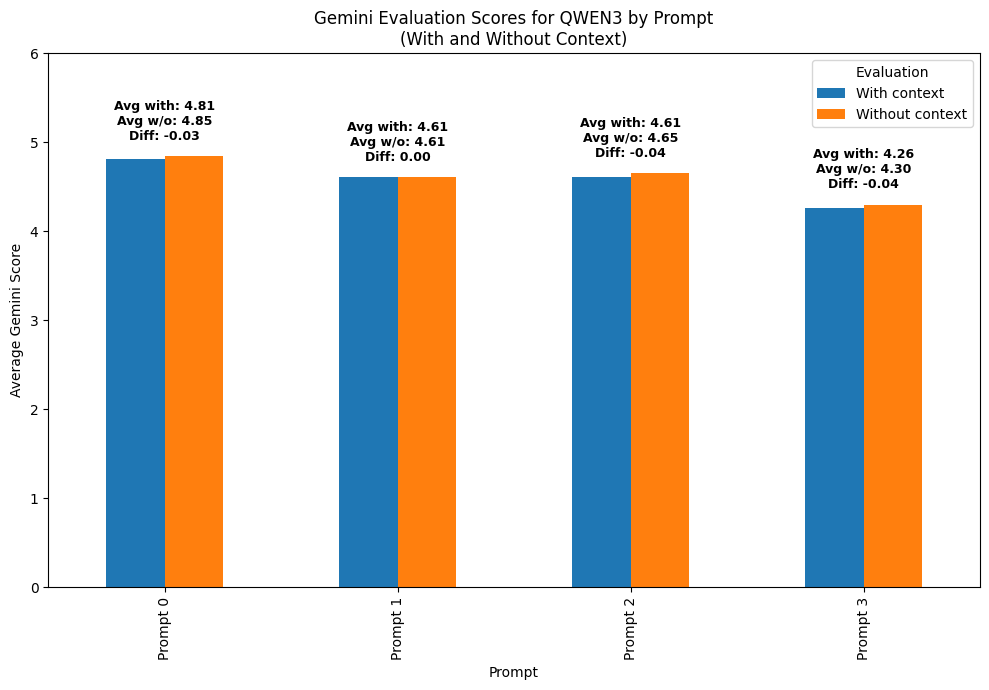

Best prompt with context in Zero_shot technique: ('Prompt 0', np.float64(4.814432989690721))


In [11]:
df = pd.read_csv('qwen3/qwen3_translations_with_eval.csv')

prompt_nums = [0, 1, 2, 3]
with_context_means = []
no_context_means = []
differences = []

for p in prompt_nums:
    wc = df[f'Modern_Italian_{p}_gemini_eval'].mean()
    nc = df[f'Modern_Italian_{p}_gemini_eval_no_context'].mean()
    with_context_means.append(wc)
    no_context_means.append(nc)
    differences.append(wc - nc)

plot_df = pd.DataFrame({
    'Prompt': [f'Prompt {p}' for p in prompt_nums],
    'With context': with_context_means,
    'Without context': no_context_means,
    'Difference': differences
})

# Plotting
ax = plot_df.set_index('Prompt')[['With context', 'Without context']].plot(kind='bar', figsize=(10,7))
plt.title('Gemini Evaluation Scores for QWEN3 by Prompt\n(With and Without Context)')
plt.ylabel('Average Gemini Score')
plt.ylim(0, 6)
plt.xlabel('Prompt')
plt.legend(title='Evaluation')
plt.tight_layout()

for idx, row in plot_df.iterrows():
    x = idx  
    y = max(row['With context'], row['Without context'])
    summary = (
        f"Avg with: {row['With context']:.2f}\n"
        f"Avg w/o: {row['Without context']:.2f}\n"
        f"Diff: {row['Difference']:.2f}"
    )
    
    plt.text(x, y+0.15, summary, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

best_zero_shot_prompt_wc = plot_df.loc[plot_df['With context'].idxmax(), 'Prompt'], plot_df['With context'].max()
print(f"Best prompt with context in Zero_shot technique: {best_zero_shot_prompt_wc}")

## Calculate average scores per prompt (Few-Shot)

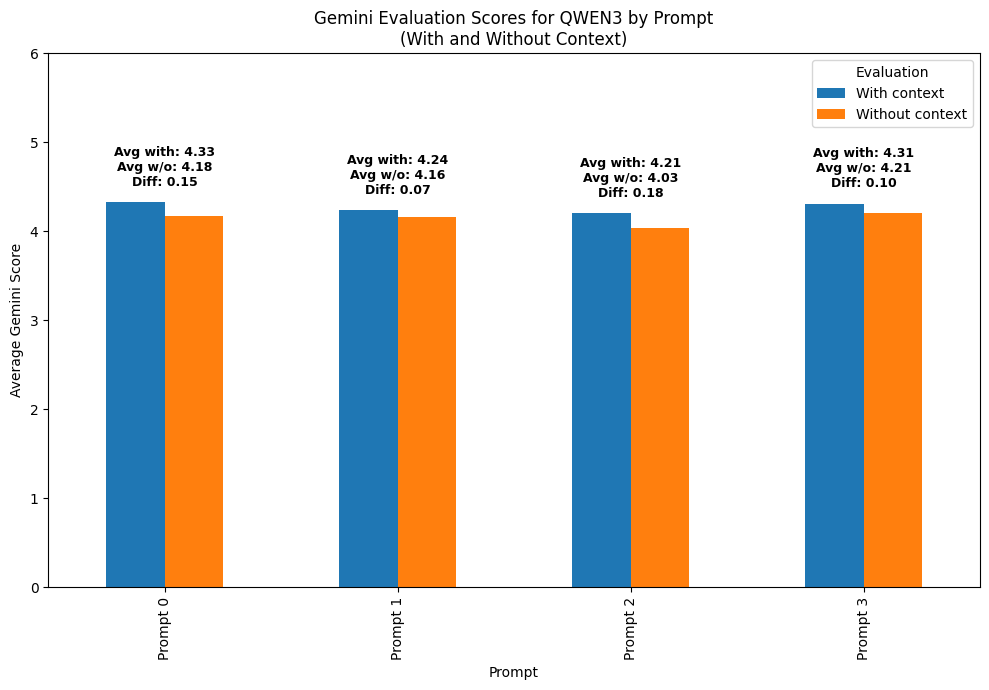

Best prompt with context in Few_shot technique: ('Prompt 0', np.float64(4.329896907216495))


In [3]:
df = pd.read_csv('qwen3/qwen3_translations_fewshot_with_eval.csv')

prompt_nums = [0, 1, 2, 3]
with_context_means = []
no_context_means = []
differences = []
best_prompt = []

for p in prompt_nums:
    wc = df[f'Modern_Italian_{p}_gemini_eval'].mean()
    nc = df[f'Modern_Italian_{p}_gemini_eval_no_context'].mean()
    with_context_means.append(wc)
    no_context_means.append(nc)
    differences.append(wc - nc)



plot_df = pd.DataFrame({
    'Prompt': [f'Prompt {p}' for p in prompt_nums],
    'With context': with_context_means,
    'Without context': no_context_means,
    'Difference': differences
})

# Plotting
ax = plot_df.set_index('Prompt')[['With context', 'Without context']].plot(kind='bar', figsize=(10,7))
plt.title('Gemini Evaluation Scores for QWEN3 by Prompt\n(With and Without Context)')
plt.ylabel('Average Gemini Score')
plt.ylim(0, 6)
plt.xlabel('Prompt')
plt.legend(title='Evaluation')
plt.tight_layout()

for idx, row in plot_df.iterrows():
    x = idx  
    y = max(row['With context'], row['Without context'])
    summary = (
        f"Avg with: {row['With context']:.2f}\n"
        f"Avg w/o: {row['Without context']:.2f}\n"
        f"Diff: {row['Difference']:.2f}"
    )
    
    plt.text(x, y+0.15, summary, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

best_few_shot_prompt_wc = plot_df.loc[plot_df['With context'].idxmax(), 'Prompt'], plot_df['With context'].max() # (prompt, score)
print(f"Best prompt with context in Few_shot technique: {best_few_shot_prompt_wc}")


## The best prompt technique in QWEN3 model

In [4]:
qwen3_zero = pd.read_csv('qwen3/qwen3_translations_with_eval.csv')
qwen3_few = pd.read_csv('qwen3/qwen3_translations_fewshot_with_eval.csv')

def qwen3_best_prompt_from_df(df, context_type):
    prompt_nums = [0, 1, 2, 3]
    means = []
    for p in prompt_nums:
        means.append(df[f'Modern_Italian_{p}_gemini_eval' + ('' if context_type == 'with' else '_no_context')].mean())
    best_idx = int(np.argmax(means))
    return f'Prompt {best_idx}', means[best_idx], best_idx

# Get best prompt and score for zero-shot and few-shot, with and without context
qwen3_best_zero_prompt_with, qwen3_best_zero_score_with, idx_zero = qwen3_best_prompt_from_df(qwen3_zero, 'with')
qwen3_best_zero_prompt_without, qwen3_best_zero_score_without, _ = qwen3_best_prompt_from_df(qwen3_zero, 'without')
qwen3_best_few_prompt_with, qwen3_best_few_score_with, idx_few = qwen3_best_prompt_from_df(qwen3_few, 'with')
qwen3_best_few_prompt_without, qwen3_best_few_score_without, _ = qwen3_best_prompt_from_df(qwen3_few, 'without')

if qwen3_best_zero_score_with >= qwen3_best_few_score_with:
    qwen3_best_prompt_name_with = qwen3_best_zero_prompt_with
    qwen3_best_prompt_score_with = qwen3_best_zero_score_with
    technique_with = 'Zero-shot'
    idx_best = idx_zero
    qwen3_best_df = qwen3_zero
else:
    qwen3_best_prompt_name_with = qwen3_best_few_prompt_with
    qwen3_best_prompt_score_with = qwen3_best_few_score_with
    technique_with = 'Few-shot'
    idx_best = idx_few
    qwen3_best_df = qwen3_few

if qwen3_best_zero_score_without >= qwen3_best_few_score_without:
    qwen3_best_prompt_name_without = qwen3_best_zero_prompt_without
    qwen3_best_prompt_score_without = qwen3_best_zero_score_without
    technique_without = 'Zero-shot'
else:
    qwen3_best_prompt_name_without = qwen3_best_few_prompt_without
    qwen3_best_prompt_score_without = qwen3_best_few_score_without
    technique_without = 'Few-shot'

print(f"Best prompt in QWEN3 with context: {qwen3_best_prompt_name_with}, Score: {qwen3_best_prompt_score_with}, Technique: {technique_with}")
print(f"Best prompt in QWEN3 without context: {qwen3_best_prompt_name_without}, Score: {qwen3_best_prompt_score_without}, Technique: {technique_without}")

Best prompt in QWEN3 with context: Prompt 0, Score: 4.814432989690721, Technique: Zero-shot
Best prompt in QWEN3 without context: Prompt 0, Score: 4.845360824742268, Technique: Zero-shot


# The overall view on all models

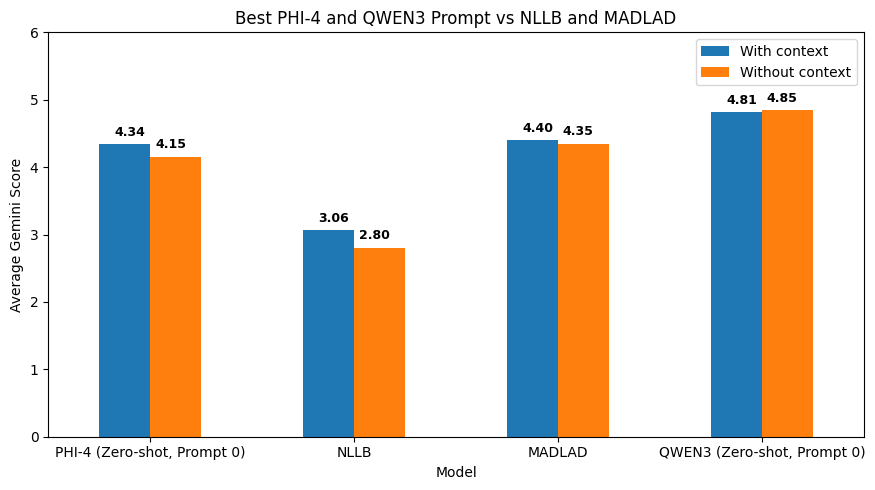

In [27]:
nllb = pd.read_csv('nllb/nllb_translations_with_eval.csv')
madlad = pd.read_csv('madlad/madlad_translations_with_eval.csv')

nllb_score_with = nllb['gemini_eval'].mean()
nllb_score_without = nllb['gemini_eval_no_context'].mean()
madlad_score_with = madlad['gemini_eval'].mean()
madlad_score_without = madlad['gemini_eval_no_context'].mean()

bar_df = pd.DataFrame({
    'Model': [ f'PHI-4 ({technique_with}, {best_prompt_name_with})','NLLB', 'MADLAD', f'QWEN3 ({technique_with}, {qwen3_best_prompt_name_with})'],
    'With context': [nllb_score_with, madlad_score_with, best_prompt_score_with, qwen3_best_prompt_score_with],
    'Without context': [nllb_score_without, madlad_score_without, best_prompt_score_without, qwen3_best_prompt_score_without]
}).set_index('Model')

ax = bar_df.plot(kind='bar', figsize=(9,5), color=['#1f77b4', '#ff7f0e'])
plt.title('Best PHI-4 and QWEN3 Prompt vs NLLB and MADLAD')
plt.ylabel('Average Gemini Score')
plt.ylim(0, 6)
plt.xticks(rotation=0)  


for i, model in enumerate(bar_df.index):
    for j, context in enumerate(['With context', 'Without context']):
        v = bar_df.loc[model, context]
        plt.text(i + (j-0.5)*0.20, v + 0.08, f"{v:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


# Human Ratings Visualization

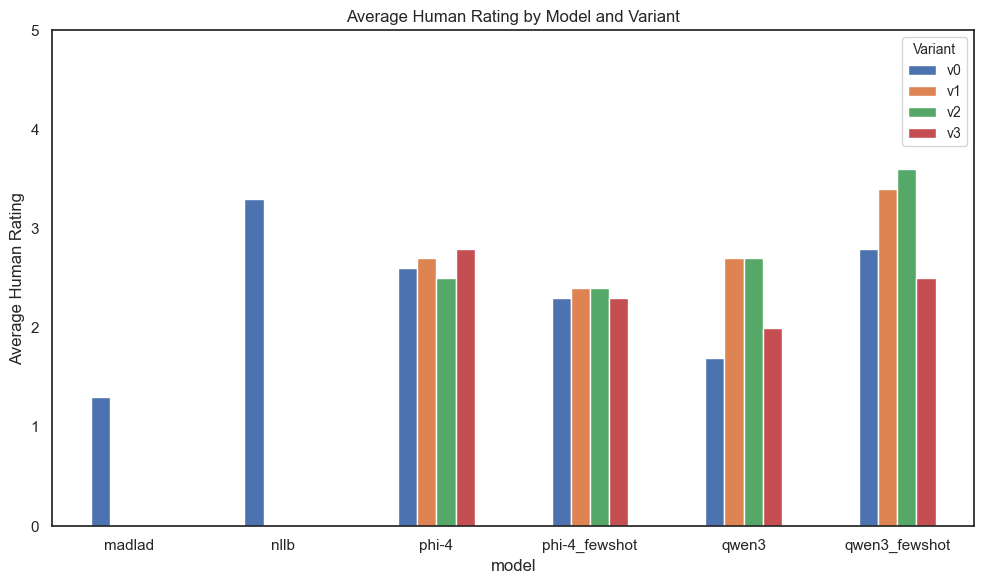

In [56]:
df = pd.read_csv("human_ratings.csv", header=1)

for model in ["madlad", "nllb"]:
    df.loc[(df["model"] == model) & (df["variant"].isnull()), "variant"] = "v0"

df["human_rating"] = pd.to_numeric(df["human_rating"], errors="coerce")

avg_ratings = df.groupby(["model", "variant"])["human_rating"].mean().reset_index()
pivot_df = avg_ratings.pivot(index="model", columns="variant", values="human_rating")

pivot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Average Human Rating by Model and Variant")
plt.ylabel("Average Human Rating")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.legend(title="Variant", fontsize="small", title_fontsize="small")
plt.tight_layout()
plt.show()


# Correlation between Human and LLM ratings

In [12]:
human_df = pd.read_csv("human_ratings.csv", header=1)

# Fill missing variants with "v0" for madlad and nllb
for model in ["madlad", "nllb"]:
    mask = (human_df["model"] == model) & (human_df["variant"].isnull())
    human_df.loc[mask, "variant"] = "v0"

# Define function to compute kappa
def compute_kappa_for_variant(human_df, llm_df, model_name, variant, llm_score_col, context_types=["with", "without"]):
    h_sub = human_df[(human_df["model"] == model_name) & (human_df["variant"] == variant)].reset_index(drop=True)
    l_sub = llm_df.iloc[:len(h_sub)].reset_index(drop=True)
    kappas = []
    
    for context in context_types:
        if context == "with":
            llm_scores = l_sub[llm_score_col].tolist()
        elif context == "without":
            llm_scores = l_sub[llm_score_col + "_no_context"].tolist()
        
        human_scores = h_sub["human_rating"].tolist()
        
        if len(human_scores) > 0 and len(llm_scores) > 0:
            kappa = cohen_kappa_score(human_scores, llm_scores)
        else:
            kappa = float("nan")
        
        kappas.append({
            "model": model_name,
            "variant": variant,
            "context": context,
            "kappa": kappa
        })
    
    return kappas

# Load model prediction files
madlad_df = pd.read_csv("madlad/madlad_translations_with_eval.csv")
nllb_df = pd.read_csv("nllb/nllb_translations_with_eval.csv")
phi4_df = pd.read_csv("phi-4/phi-4_translations_with_eval.csv")
phi4few_df = pd.read_csv("phi-4/phi-4_translations_fewshot_with_eval.csv")
qwen3_df = pd.read_csv("qwen3/qwen3_translations_with_eval.csv")
qwen3few_df = pd.read_csv("qwen3/qwen3_translations_fewshot_with_eval.csv")

all_results = []

# For MADLAD and NLLB
for variant in human_df[human_df["model"] == "madlad"]["variant"].unique():
    all_results += compute_kappa_for_variant(human_df, madlad_df, "madlad", variant, "gemini_eval")

for variant in human_df[human_df["model"] == "nllb"]["variant"].unique():
    all_results += compute_kappa_for_variant(human_df, nllb_df, "nllb", variant, "gemini_eval")

# For phi-4 and phi-4_fewshot
for variant in ["v0", "v1", "v2", "v3"]:
    llm_score_col = f"Modern_Italian_{variant[-1]}_gemini_eval"
    all_results += compute_kappa_for_variant(human_df, phi4_df, "phi-4", variant, llm_score_col)
    all_results += compute_kappa_for_variant(human_df, phi4few_df, "phi-4_fewshot", variant, llm_score_col)

# For qwen3 and qwen3_fewshot
for variant in ["v0", "v1", "v2", "v3"]:
    llm_score_col = f"Modern_Italian_{variant[-1]}_gemini_eval"
    all_results += compute_kappa_for_variant(human_df, qwen3_df, "qwen3", variant, llm_score_col)
    all_results += compute_kappa_for_variant(human_df, qwen3few_df, "qwen3_fewshot", variant, llm_score_col)

# Save and display
kappa_results = pd.DataFrame(all_results)
kappa_results.to_csv("kappa_results.csv", index=False)
print(kappa_results.head(100))

            model variant  context         kappa
0          madlad      v0     with -4.651163e-02
1          madlad      v0  without -8.695652e-02
2            nllb      v0     with -2.564103e-02
3            nllb      v0  without  4.736842e-01
4           phi-4      v0     with -1.235955e-01
5           phi-4      v0  without -1.363636e-01
6   phi-4_fewshot      v0     with  2.173913e-02
7   phi-4_fewshot      v0  without  2.173913e-02
8           phi-4      v1     with -1.363636e-01
9           phi-4      v1  without -1.363636e-01
10  phi-4_fewshot      v1     with  3.225806e-02
11  phi-4_fewshot      v1  without -1.235955e-01
12          phi-4      v2     with  5.882353e-02
13          phi-4      v2  without  1.954023e-01
14  phi-4_fewshot      v2     with  5.882353e-02
15  phi-4_fewshot      v2  without  9.090909e-02
16          phi-4      v3     with  1.566265e-01
17          phi-4      v3  without  2.857143e-01
18  phi-4_fewshot      v3     with  0.000000e+00
19  phi-4_fewshot   

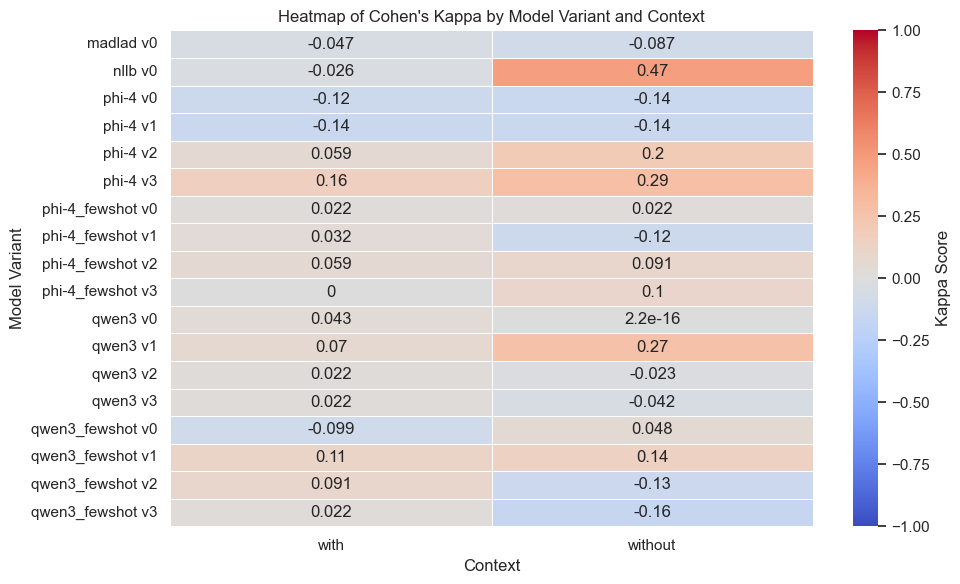

In [13]:
kappa_df = pd.read_csv("kappa_results.csv")

kappa_df["model_variant"] = kappa_df["model"] + " " + kappa_df["variant"]

heatmap_data = kappa_df.pivot(index="model_variant", columns="context", values="kappa")

plt.figure(figsize=(10, 6))
sns.set(style="white")

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Kappa Score"}
)

plt.title("Heatmap of Cohen's Kappa by Model Variant and Context")
plt.xlabel("Context")
plt.ylabel("Model Variant")
plt.tight_layout()
plt.show()

# Confusion_Matrix

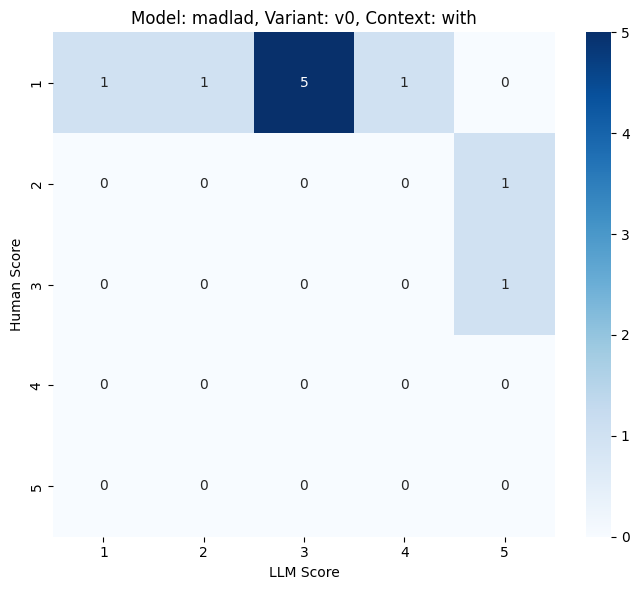

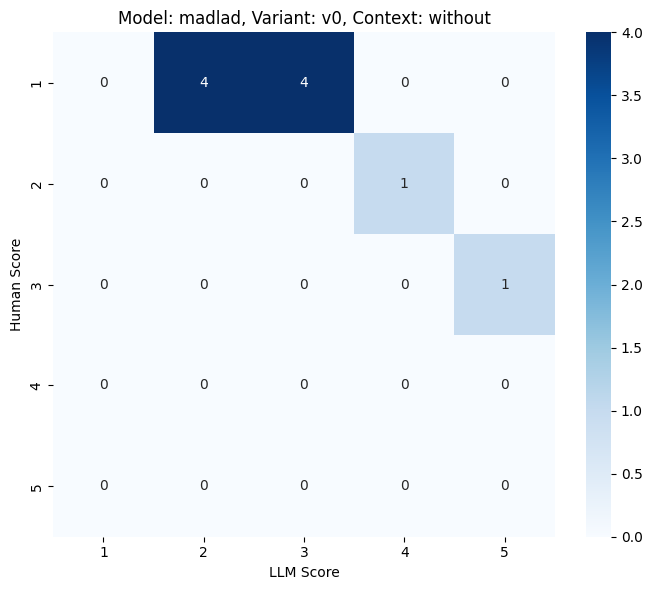

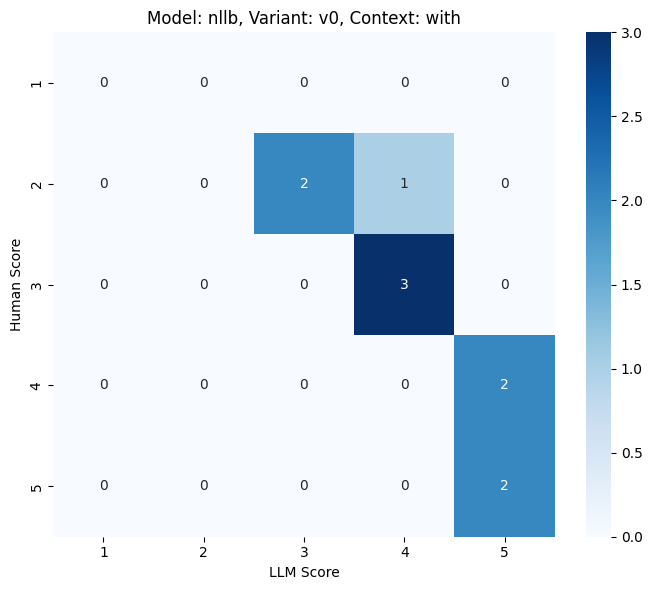

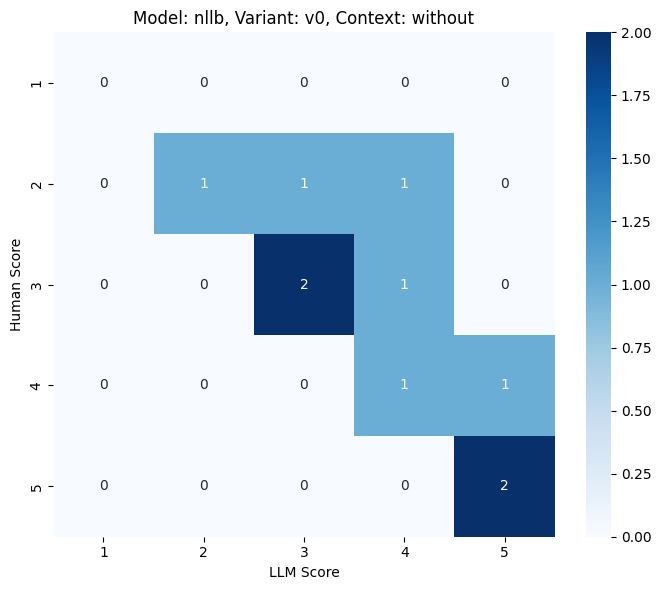

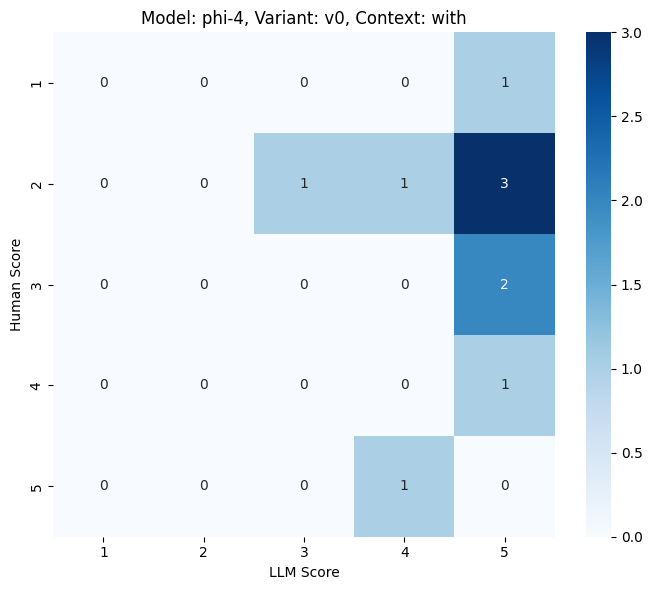

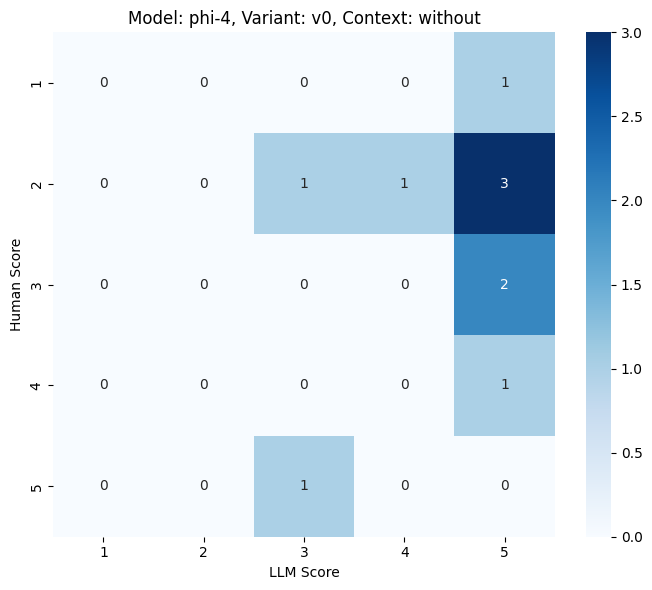

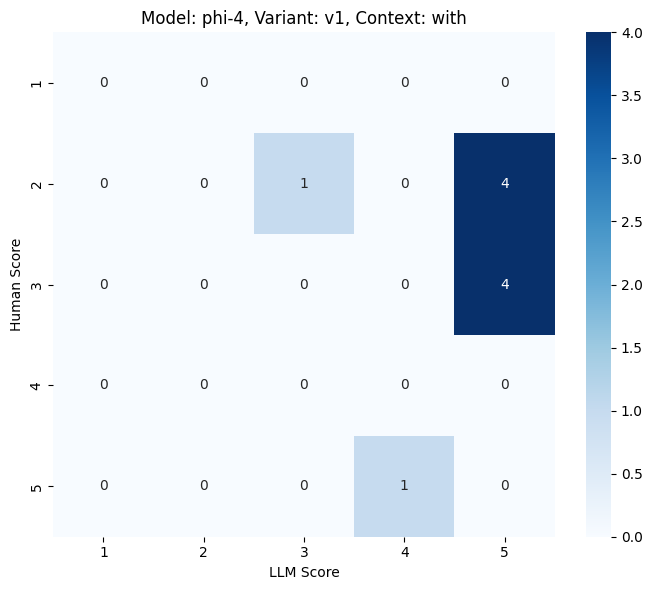

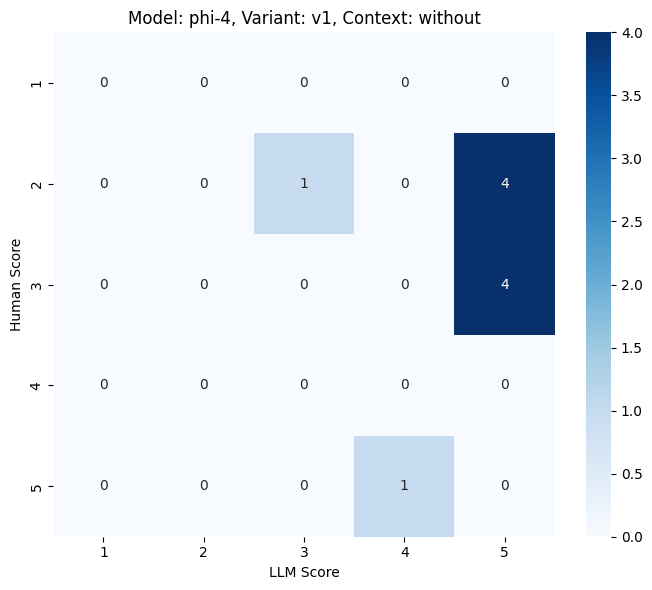

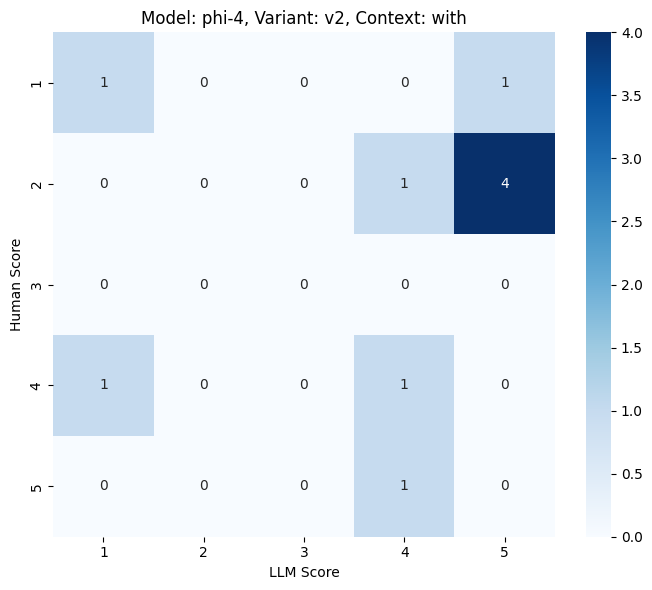

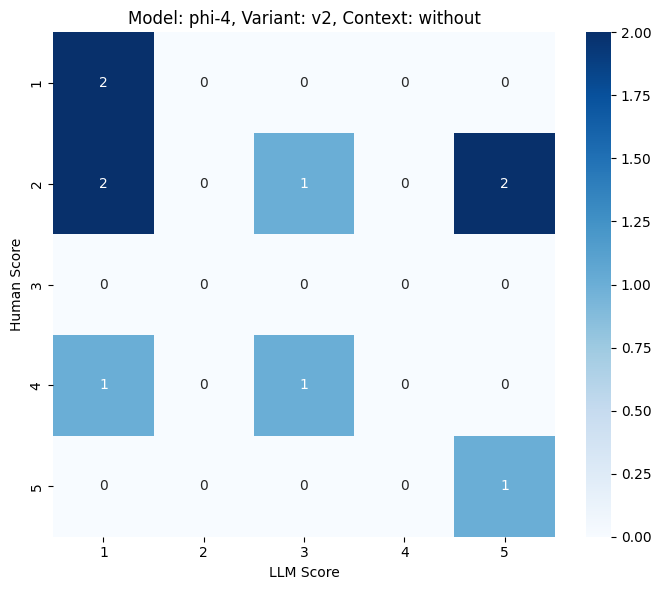

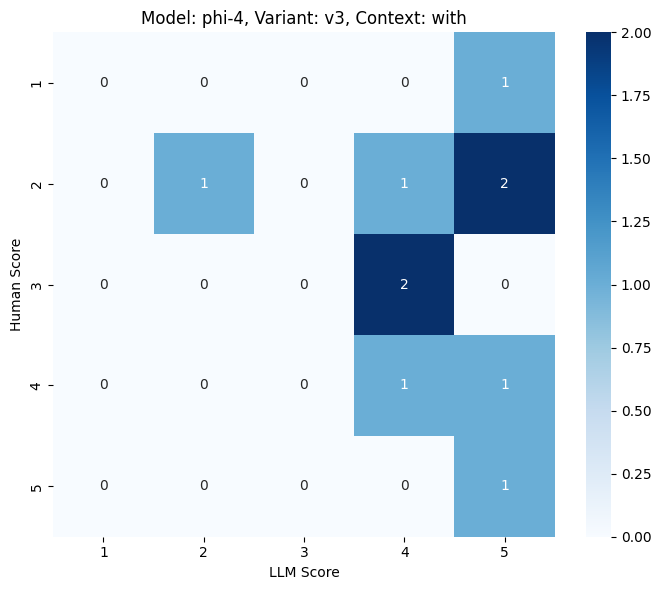

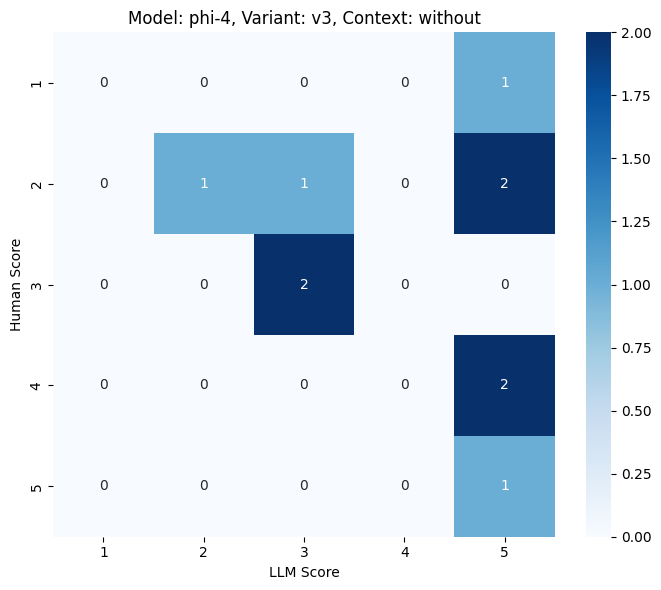

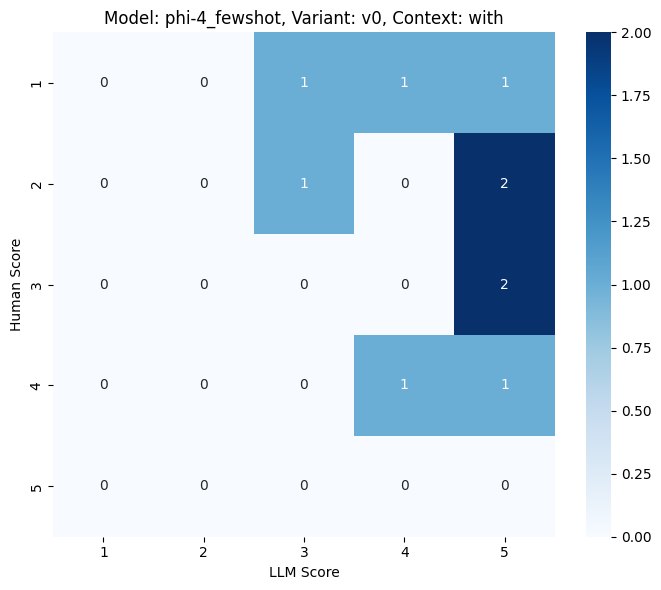

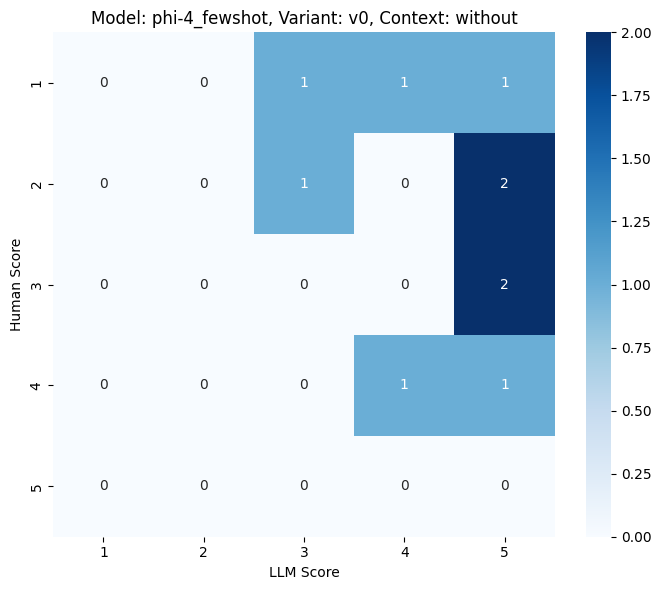

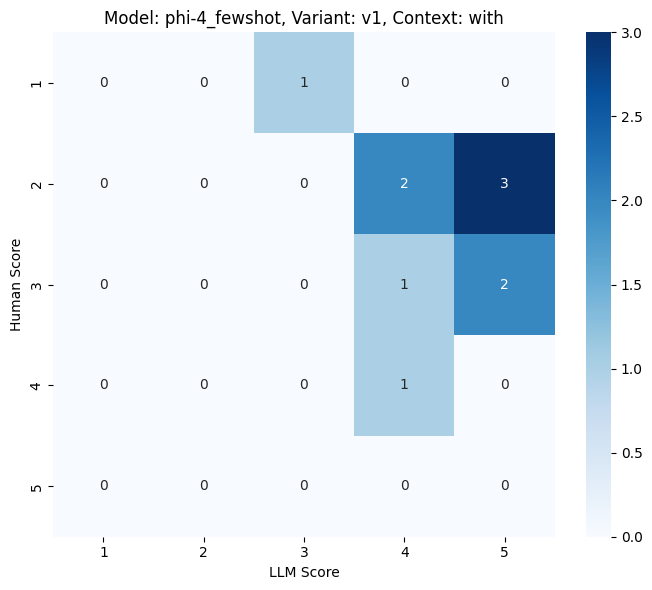

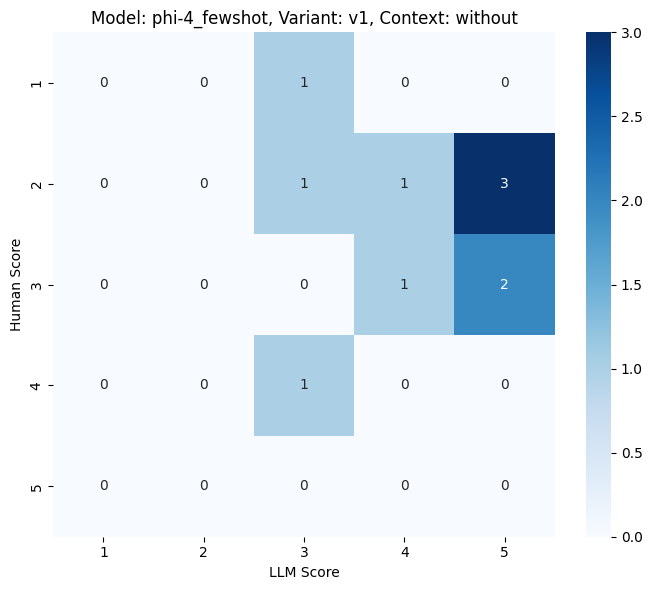

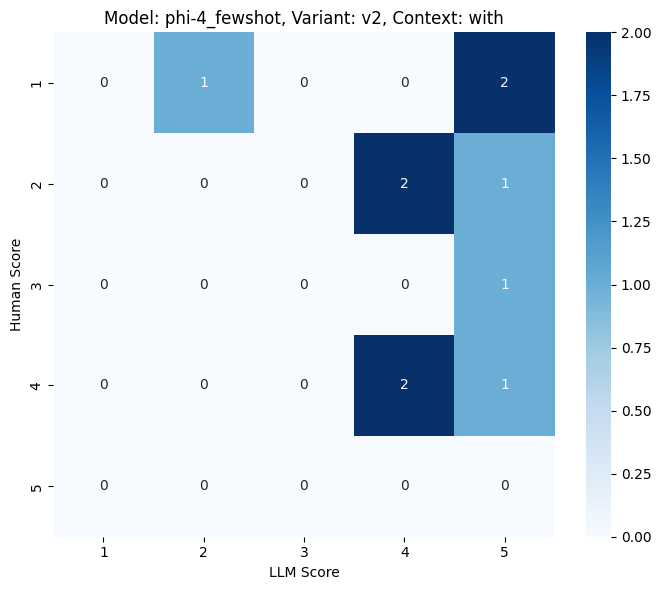

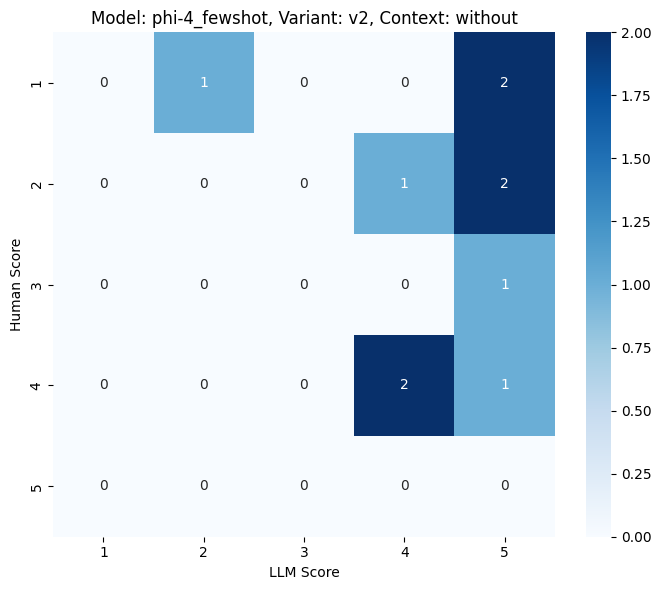

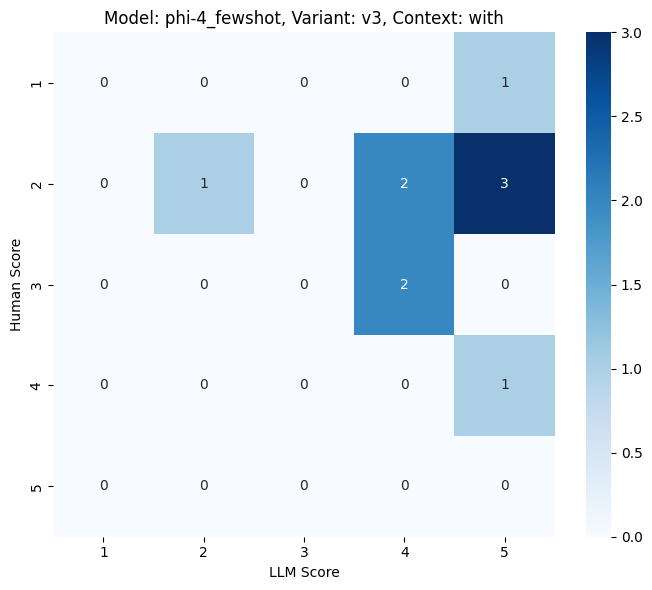

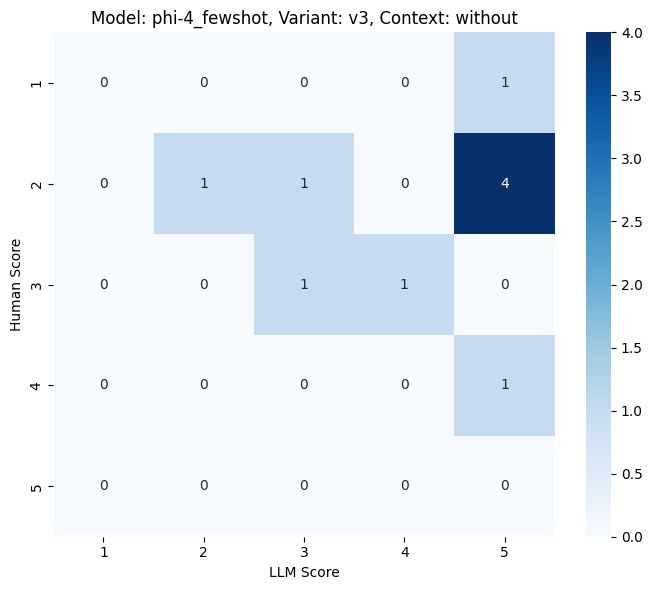

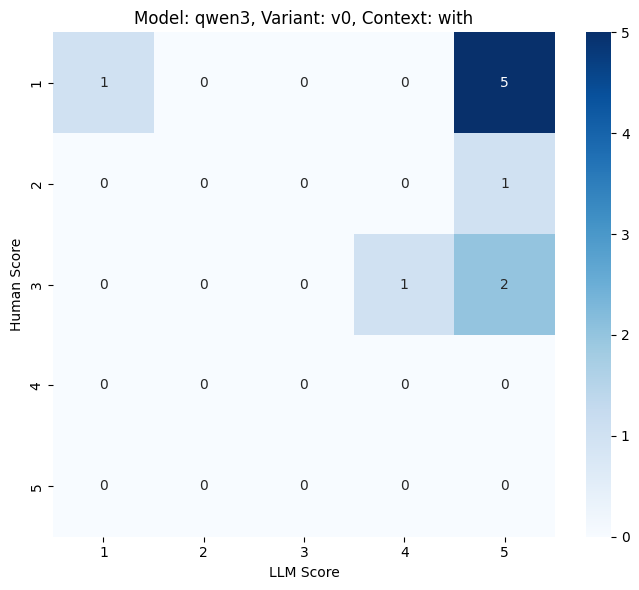

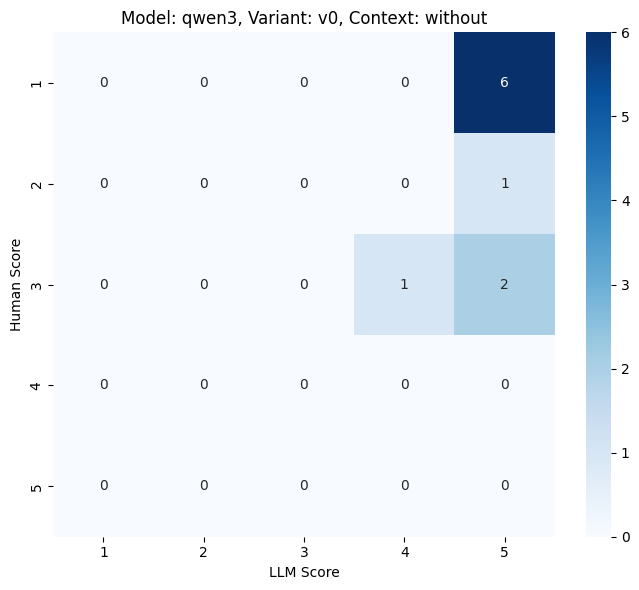

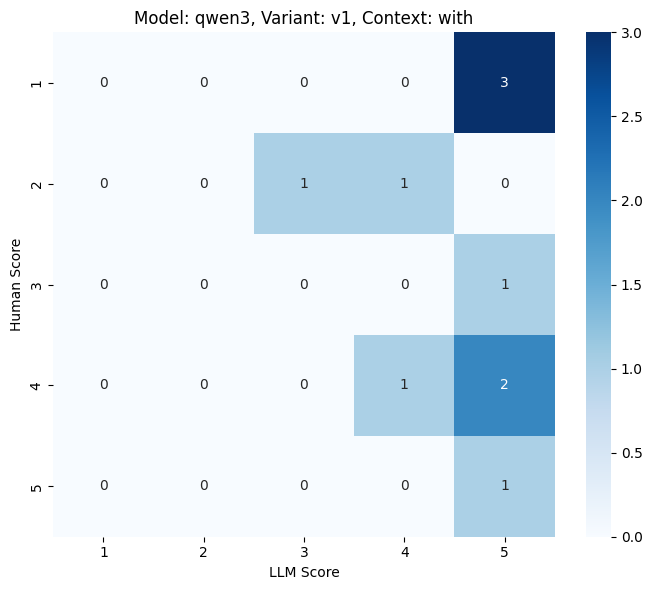

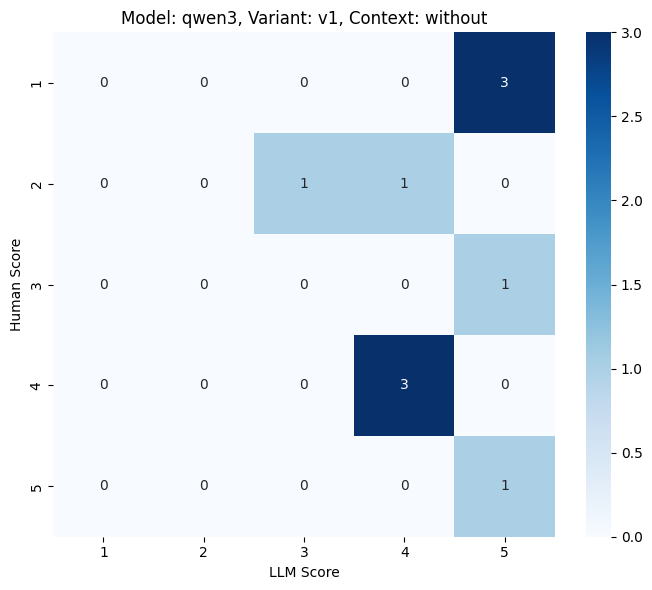

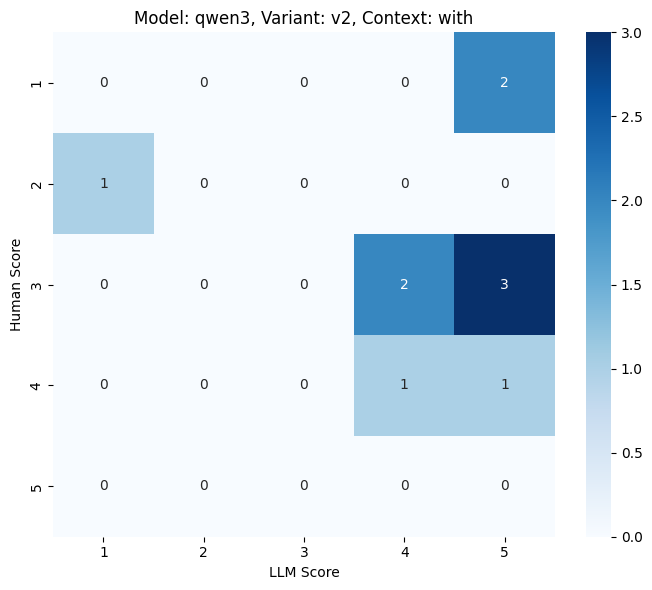

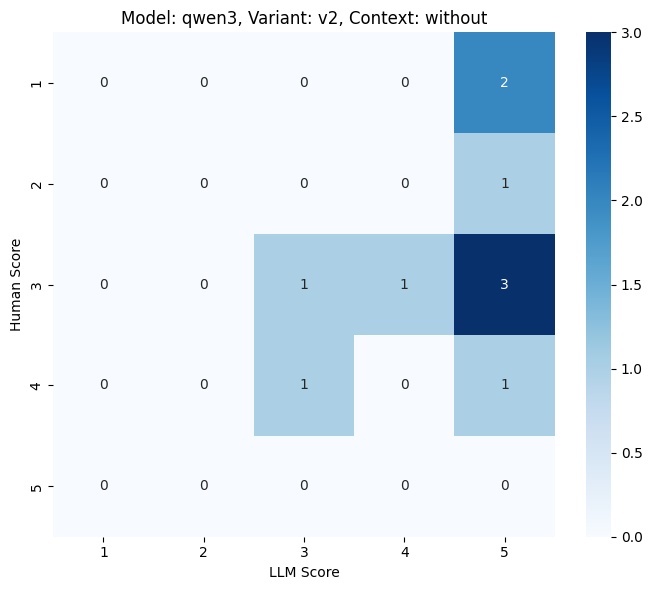

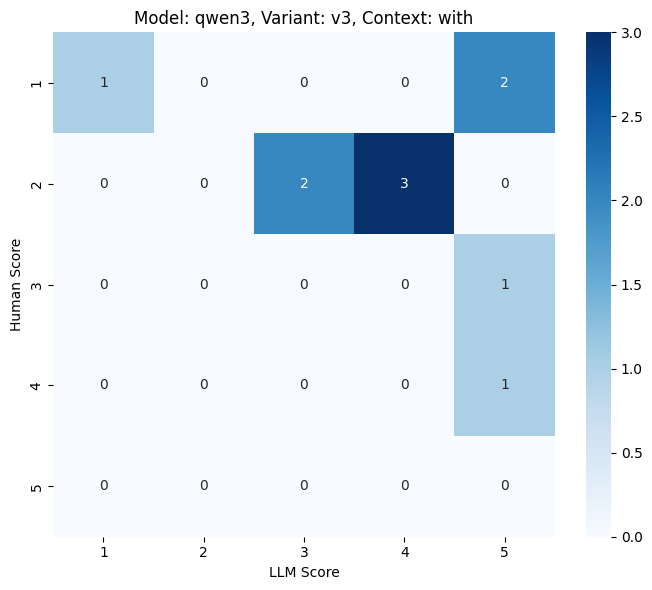

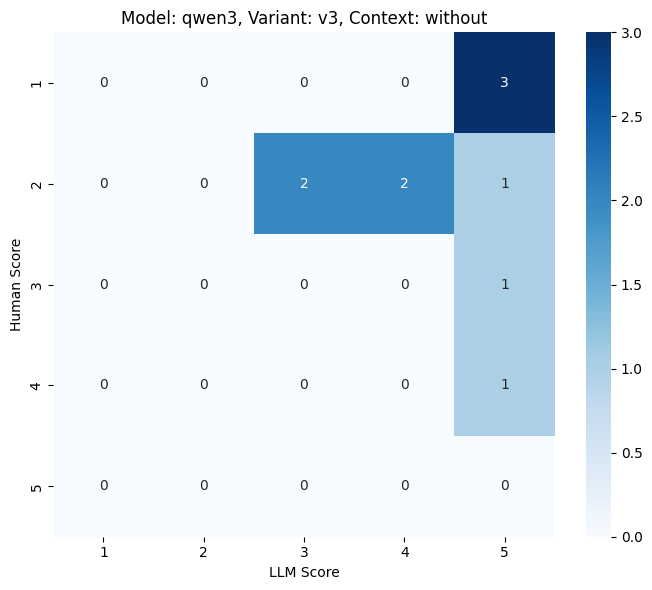

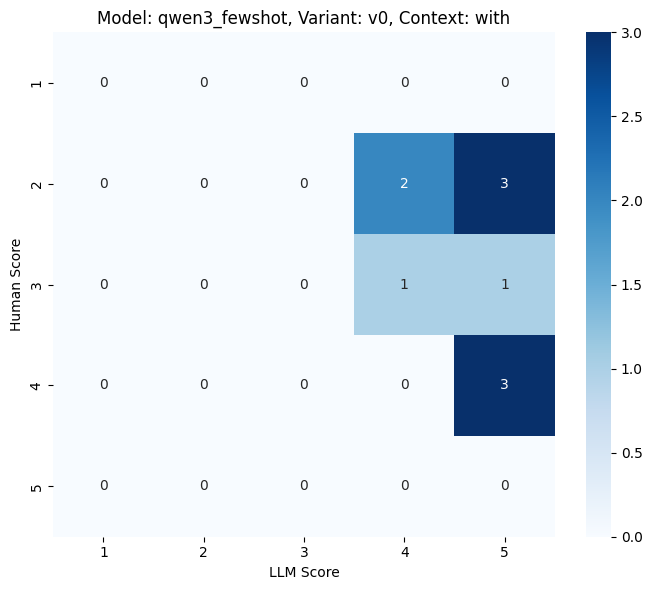

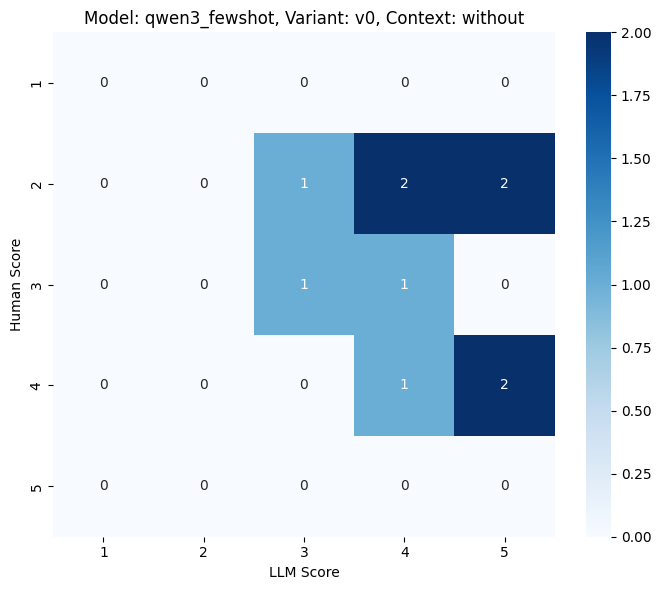

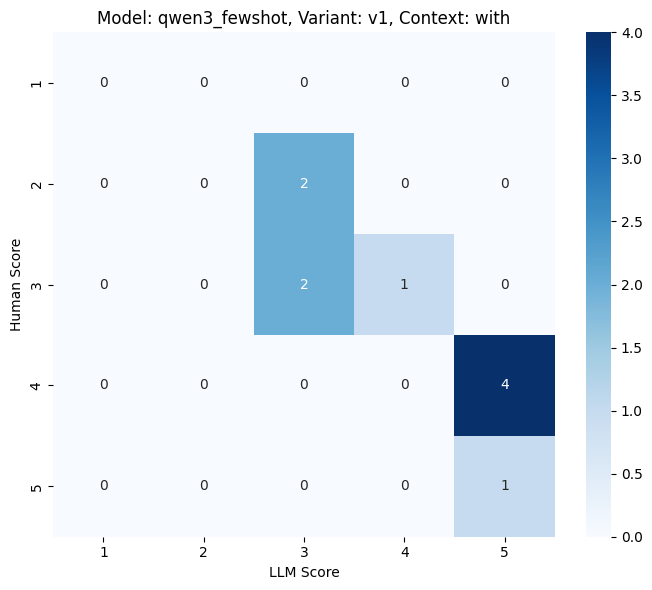

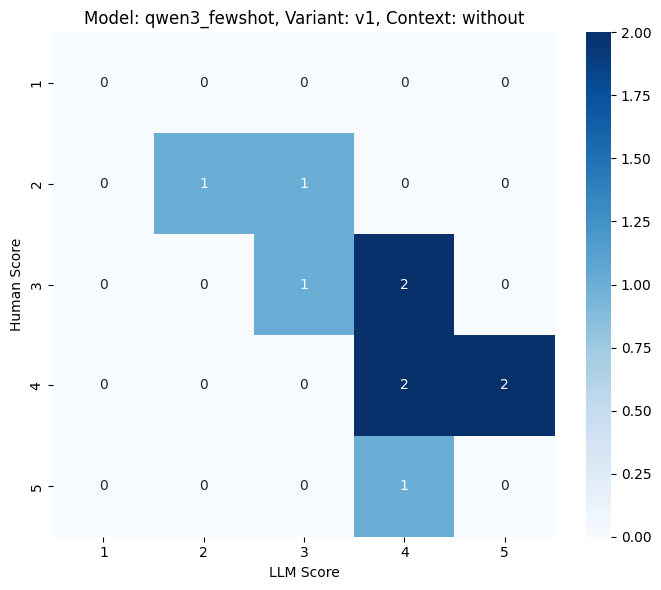

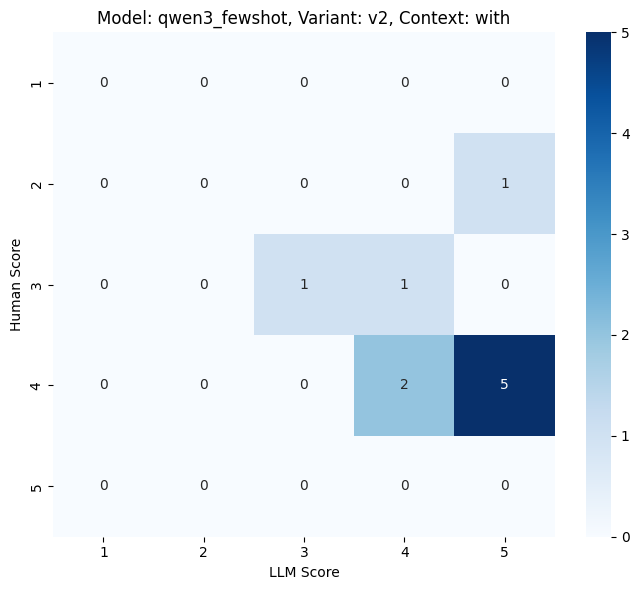

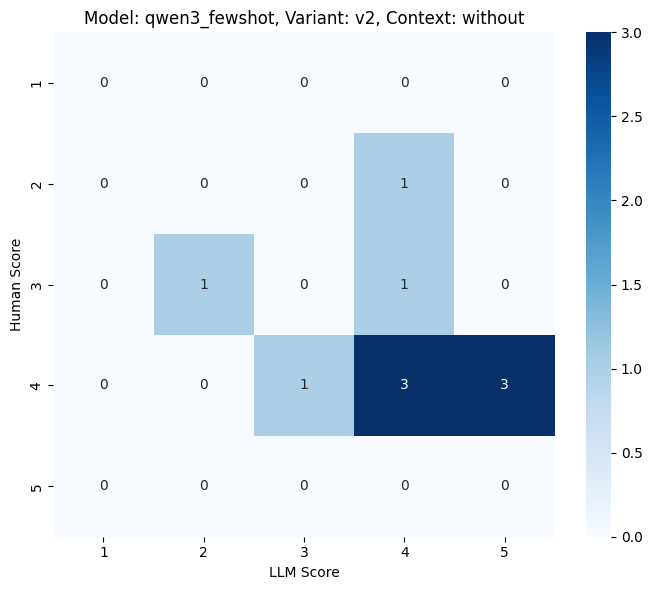

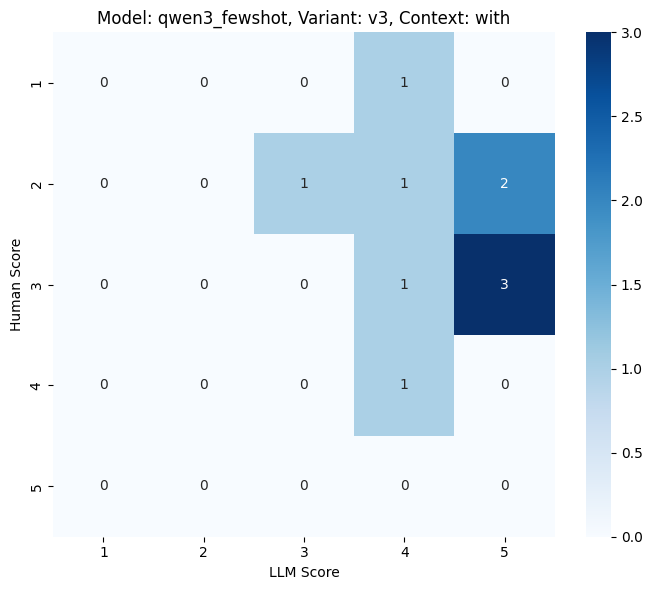

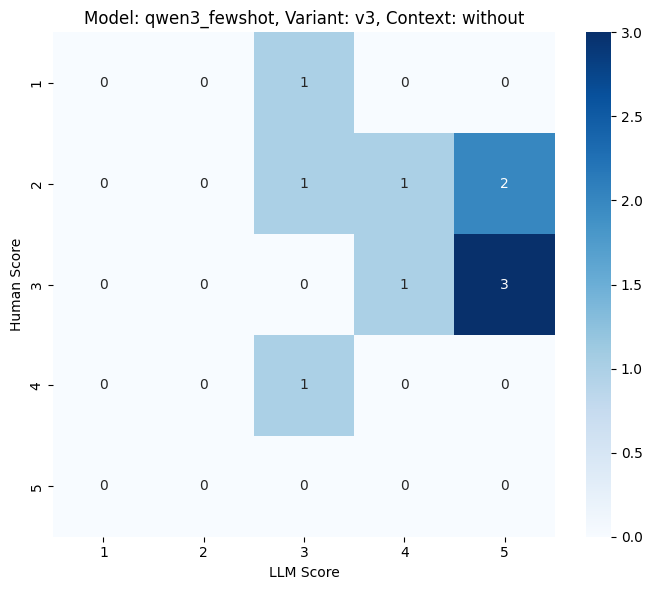

In [35]:
labels = [1, 2, 3, 4, 5]

# Deduplicate to ensure only one plot per row as in kappa_results
kappa_results_unique = kappa_results.drop_duplicates(subset=["model", "variant", "context"])

for idx, row in kappa_results_unique.iterrows():
    model = row["model"]
    variant = row["variant"]
    context = row["context"]

    # Get correct LLM dataframe and column
    if model == "madlad":
        llm_score_col = "gemini_eval"
        llm_df = madlad_df
    elif model == "nllb":
        llm_score_col = "gemini_eval"
        llm_df = nllb_df
    elif model == "phi-4":
        match = re.match(r"v(\d+)", str(variant))
        if match:
            idx_variant = int(match.group(1))
            llm_score_col = f"Modern_Italian_{idx_variant}_gemini_eval"
            llm_df = phi4_df
        else:
            continue
    elif model == "phi-4_fewshot":
        match = re.match(r"v(\d+)", str(variant))
        if match:
            idx_variant = int(match.group(1))
            llm_score_col = f"Modern_Italian_{idx_variant}_gemini_eval"
            llm_df = phi4few_df
        else:
            continue
    elif model == "qwen3":
        match = re.match(r"v(\d+)", str(variant))
        if match:
            idx_variant = int(match.group(1))
            llm_score_col = f"Modern_Italian_{idx_variant}_gemini_eval"
            llm_df = qwen3_df
        else:
            continue
    elif model == "qwen3_fewshot":
        match = re.match(r"v(\d+)", str(variant))
        if match:
            idx_variant = int(match.group(1))
            llm_score_col = f"Modern_Italian_{idx_variant}_gemini_eval"
            llm_df = qwen3few_df
        else:
            continue
    else:
        continue

    h_sub = human_df[(human_df["model"] == model) & (human_df["variant"] == variant)].reset_index(drop=True)
    l_sub = llm_df.iloc[:len(h_sub)].reset_index(drop=True)

    if context == "with":
        llm_scores = l_sub[llm_score_col].tolist()
    elif context == "without":
        llm_scores = l_sub[llm_score_col + "_no_context"].tolist()
    else:
        continue

    human_scores = h_sub["human_rating"].tolist()

    if len(human_scores) > 0 and len(llm_scores) > 0:
        cm = confusion_matrix(human_scores, llm_scores, labels=labels)
        plt.figure(figsize=(7,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=labels, yticklabels=labels, cbar=True)
        plt.xlabel("LLM Score")
        plt.ylabel("Human Score")
        plt.title(f"Model: {model}, Variant: {variant}, Context: {context}")
        plt.tight_layout()
        plt.show()
